# Домашенее задание №2: 3-D модели

In [18]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

import trimesh
from trimesh.voxel import ops as voxel_ops

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


<i><b>Замечание:</b> Поскольку у меня нет GPU, в моделях ниже пришлось уменьшить количество вокселей и переделать модели соответствующим образом. Ниже оставлен только измененный код. Количество эпох для обучения не меняла. Все ровно так, как обсуждали на занятии, только с немного скорректиорванными архитектурами. </i>

## Бонус: формула attention
Сделано на семинаре. Не имеет прямого отношения к остальному коду, но так как уже было сделано решила не удалять &#x1F600;

In [19]:
np.random.seed(SEED)
X = np.array([
    [1, 5, 1, 3, 5],
    [2, 5, 1, 3, 5],
    [2, 3, 1, 3, 5]
])

X.shape

Wq = np.random.randn(5, 5)
Wk = np.random.randn(5, 5)
Wv = np.random.randn(5, 5)

Q = X @ Wq
K = X @ Wk
V = Q @ Wv

scores = Q @ K.T / X.shape[1]

exp_scores = np.exp(scores)

softmax_scores = exp_scores / exp_scores.sum(axis=-1, keepdims = True)

output = softmax_scores @ V

print(output)

# Attention = Softmax((Q * K.T) / np.sqrt(x.shape[1])) * V

[[-16.38776536 -14.66373612 -22.59040029 -17.94029629  37.38555646]
 [-16.41808244 -14.64386947 -22.54679525 -17.94169347  37.35828747]
 [-16.67985139 -14.33553059 -21.26670753 -18.07848947  36.82004147]]


In [20]:
DATA_DIR = Path(r"dataset")
CACHE_DIR = DATA_DIR / "_voxel_cache_64"
CACHE_DIR.mkdir(exist_ok=True)

VOXEL_SIZE = 16
IMAGE_SIZE = 64

png_files = sorted(DATA_DIR.glob('*.png'))
pairs = []
for img_path in png_files:
    stl_path = img_path.with_suffix('.stl')
    if stl_path.exists():
        pairs.append((img_path, stl_path))

print(f'Found pairs: {len(pairs)}')


Found pairs: 561


In [21]:
def load_mesh(mesh_path: Path) -> trimesh.Trimesh:
    mesh = trimesh.load(mesh_path, force='mesh')
    if isinstance(mesh, trimesh.Scene):
        if len(mesh.geometry) == 0:
            raise ValueError(f'Empty scene: {mesh_path}')
        mesh = trimesh.util.concatenate(list(mesh.geometry.values()))
    return mesh

def mesh_to_voxel_grid(mesh_path: Path, grid_size: int = 16, pad: int = 2) -> np.ndarray:
    mesh = load_mesh(mesh_path).copy()

    verts = mesh.vertices
    vmin = verts.min(axis=0)
    vmax = verts.max(axis=0)
    span = np.maximum(vmax - vmin, 1e-6)

    verts = (verts - vmin) / span.max()
    scale = grid_size - 1 - 2 * pad
    verts = verts * scale + pad
    mesh.vertices = verts

    vox = mesh.voxelized(pitch=1.0)
    vox = vox.fill()
    points = np.round(vox.points).astype(np.int32)

    grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)
    valid = (
        (points[:, 0] >= 0) & (points[:, 0] < grid_size) &
        (points[:, 1] >= 0) & (points[:, 1] < grid_size) &
        (points[:, 2] >= 0) & (points[:, 2] < grid_size)
    )
    points = points[valid]
    grid[points[:, 0], points[:, 1], points[:, 2]] = 1.0
    return grid

class ImageToVoxelDataset(Dataset):
    def __init__(self, pairs, voxel_size=32, image_size=128, cache_dir=None):
        self.pairs = pairs
        self.voxel_size = voxel_size
        self.image_size = image_size
        self.cache_dir = cache_dir

    def __len__(self):
        return len(self.pairs)

    def _cache_file(self, stl_path: Path) -> Path:
        name = stl_path.stem + f'_vox{self.voxel_size}.npy'
        return self.cache_dir / name

    def __getitem__(self, idx):
        img_path, stl_path = self.pairs[idx]

        img = Image.open(img_path).convert('L').resize((self.image_size, self.image_size))
        img = np.asarray(img, dtype=np.float32) / 255.0
        img = torch.from_numpy(img).unsqueeze(0)

        cache_path = self._cache_file(stl_path)
        if cache_path.exists():
            vox = np.load(cache_path)
        else:
            vox = mesh_to_voxel_grid(stl_path, grid_size=self.voxel_size)
            np.save(cache_path, vox)

        vox = torch.from_numpy(vox).unsqueeze(0)
        return img, vox


### Базовая модель

<table>
<thead>
<tr><th>Блок</th><th>Описание</th></tr>
</thead>
<tbody>
<tr><td><strong>Вход</strong></td><td>Одно ч/б изображение: канал 1, размер <code>IMAGE_SIZE × IMAGE_SIZE</code>.</td></tr>
<tr><td><strong>Энкодер 2D</strong></td><td>4 уровня: каждый уровень — два блока <code>Conv2d → BatchNorm → ReLU</code>. Между уровнями — <code>MaxPool2d(2)</code> (линейный размер ÷ 2).</td></tr>
<tr><td><strong>Внимание в энкодере</strong></td><td>Уровни 1–2: <strong>SE</strong> — глобальное усреднение по H и W, два <code>Conv2d 1×1</code>, сигмоида, затем поэлементное умножение карты на эти веса по каналам. Уровни 3–4: <strong>MultiheadAttention</strong> по <code>H·W</code> токенам (размерность токена = число каналов), плюс MLP и остаточные связи внутри блока.</td></tr>
<tr><td><strong>Мост</strong></td><td><code>Conv2d</code> на 256 каналах, затем <code>AdaptiveAvgPool2d</code> до <code>4×4</code>. Тензор <code>B×256×4×4</code> превращают в <code>B×256×4×4×4</code> (ось глубины куба совпадает с «лишней» осью, полученной из плоского квадрата).</td></tr>
<tr><td><strong>Декодер 3D</strong></td><td>4 шага: <code>ConvTranspose3d</code> (×2 по каждой оси), <strong>сложение</strong> со skip из энкодера (проекция <code>1×1</code>, пулинг до <code>D×D</code>, повтор по глубине до <code>D×D×D</code>), затем <strong>два</strong> <code>ConvBlock3D</code>.</td></tr>
<tr><td><strong>Выход</strong></td><td><code>Conv3d 1×1</code> → логиты <code>VOXEL_SIZE³</code>.</td></tr>
</tbody>
</table>


In [ ]:
# ИЗМЕНЕННАЯ БАЗОВАЯ МОДЕЛЬ #
class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SEBlock2d(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, mid, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(x)


class SpatialSelfAttention2d(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4, ffn_mult: int = 2):
        super().__init__()
        if channels % num_heads != 0:
            raise ValueError(f"channels ({channels}) must be divisible by num_heads ({num_heads})")
        self.norm1 = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(channels)
        hid = channels * ffn_mult
        self.mlp = nn.Sequential(
            nn.Linear(channels, hid),
            nn.GELU(),
            nn.Linear(hid, channels),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        seq = x.flatten(2).transpose(1, 2)  # (B, H*W, C)
        seq = seq + self.attn(self.norm1(seq), self.norm1(seq), self.norm1(seq), need_weights=False)[0]
        seq = seq + self.mlp(self.norm2(seq))
        return seq.transpose(1, 2).reshape(b, c, h, w)


class UNetLikeImageToVoxel(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.enc1 = ConvBlock2D(in_ch, 32)
        self.enc2 = ConvBlock2D(32, 64)
        self.enc3 = ConvBlock2D(64, 128)
        self.enc4 = ConvBlock2D(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.se1 = SEBlock2d(32)
        self.se2 = SEBlock2d(64)
        self.sa3 = SpatialSelfAttention2d(128, num_heads=4)
        self.sa4 = SpatialSelfAttention2d(256, num_heads=8)

        self.bridge = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.skip1 = nn.Conv2d(32, 16, 1)
        self.skip2 = nn.Conv2d(64, 32, 1)
        self.skip3 = nn.Conv2d(128, 64, 1)
        self.skip4 = nn.Conv2d(256, 128, 1)

        # 4 x 4 x 4 -> 8 x 8 x 8 -> 16 x 16 x 16
        self.up1 = nn.ConvTranspose3d(256, 128, 2, stride=2)  # 4 -> 8
        self.dec1_a = ConvBlock3D(128, 128)
        self.dec1_b = ConvBlock3D(128, 128)

        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)   # 8 -> 16
        self.dec2_a = ConvBlock3D(64, 64)
        self.dec2_b = ConvBlock3D(64, 64)

        self.up3 = None  
        self.up4 = None  

        # 16 x 16 x  16
        self.out = nn.Conv3d(64, out_ch, 1)

    def to_3d_skip_16(self, feat2d, proj, size):
        x = proj(feat2d)                          
        x = F.adaptive_avg_pool2d(x, (size, size))  
        x = x.unsqueeze(2).repeat(1, 1, size, 1, 1) 
        return x

    def forward(self, x):
        f1 = self.se1(self.enc1(x))          
        f2 = self.se2(self.enc2(self.pool(f1))) 
        f3 = self.sa3(self.enc3(self.pool(f2))) 
        f4 = self.sa4(self.enc4(self.pool(f3))) 

        b = self.bridge(f4)                     
        b = b.unsqueeze(2).repeat(1, 1, 4, 1, 1) 

        # 4 x 4 x 4 -> 8 x 8 x 8 
        x = self.up1(b)                       
        skip4 = self.to_3d_skip_16(f4, self.skip4, 8)
        x = x + skip4
        x = self.dec1_b(self.dec1_a(x))      

        # 8 x 8 x 8 -> 16 x 16 x 16
        x = self.up2(x)                        
        skip3 = self.to_3d_skip_16(f3, self.skip3, 16)
        x = x + skip3                          
        x = self.dec2_b(self.dec2_a(x))        
      
        return self.out(x)                   

In [43]:
def dice_loss_with_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(1,2,3,4))
    den = probs.sum(dim=(1,2,3,4)) + targets.sum(dim=(1,2,3,4)) + eps
    return 1 - (num / den).mean()

def combined_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dsc = dice_loss_with_logits(logits, targets)
    return 0.6 * bce + 0.4 * dsc

indices = list(range(len(pairs)))
random.shuffle(indices)
split = int(0.9 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_pairs = [pairs[i] for i in train_idx]
val_pairs = [pairs[i] for i in val_idx]

train_ds = ImageToVoxelDataset(train_pairs, voxel_size=VOXEL_SIZE, image_size=IMAGE_SIZE, cache_dir=CACHE_DIR)
val_ds = ImageToVoxelDataset(val_pairs, voxel_size=VOXEL_SIZE, image_size=IMAGE_SIZE, cache_dir=CACHE_DIR)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0)

model = UNetLikeImageToVoxel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def show_voxels(ax, vox, title, color='royalblue', step=2):
    v = vox[::step, ::step, ::step].astype(bool)
    ax.voxels(v, facecolors=color, edgecolor='k', linewidth=0.05)
    ax.set_title(title)
    ax.set_axis_off()


def plot_gt_pred_3d(gt, pred, suptitle, step=2):
    fig = plt.figure(figsize=(10, 4.5))
    ax0 = fig.add_subplot(1, 2, 1, projection='3d')
    show_voxels(ax0, gt, 'GT', color='seagreen', step=step)
    ax1 = fig.add_subplot(1, 2, 2, projection='3d')
    show_voxels(ax1, pred, 'Pred', color='royalblue', step=step)
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')


Train: 504  Val: 57


In [44]:
EPOCHS = 5
best_val = 1e9
best_path = DATA_DIR / 'best_image_to_voxel_unet_attn_3ddec.pt'

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for imgs, vox in train_loader:
        imgs = imgs.to(DEVICE)
        vox = vox.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, vox)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, vox in val_loader:
            imgs = imgs.to(DEVICE)
            vox = vox.to(DEVICE)
            logits = model(imgs)
            val_loss += combined_loss(logits, vox).item()

    train_loss /= max(len(train_loader), 1)
    val_loss /= max(len(val_loader), 1)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)

    print(f'Epoch {epoch:02d}/{EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f}')

print('Best checkpoint:', best_path)

Epoch 01/5 | train=0.4045 | val=0.3652
Epoch 02/5 | train=0.3115 | val=0.3083
Epoch 03/5 | train=0.2875 | val=0.2536
Epoch 04/5 | train=0.2671 | val=0.2516
Epoch 05/5 | train=0.2659 | val=0.2461
Best checkpoint: dataset\best_image_to_voxel_unet_attn_3ddec.pt


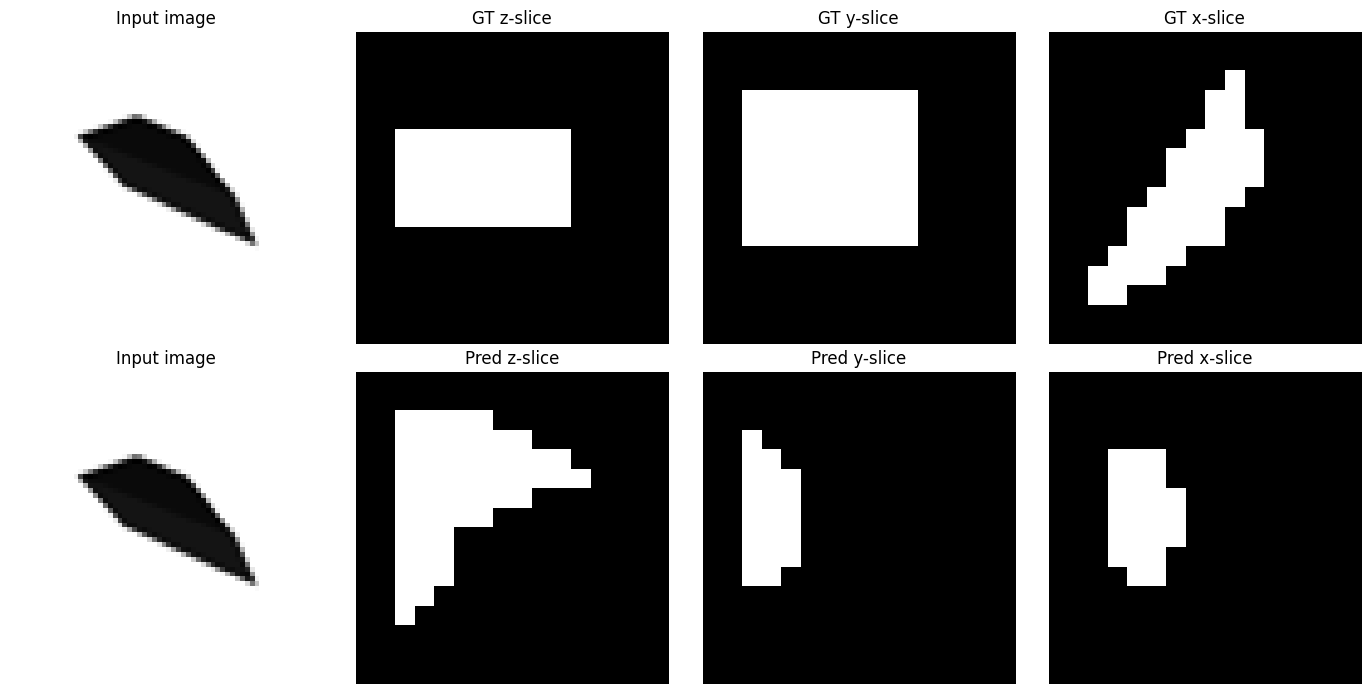

In [45]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

img, gt = val_ds[0]
with torch.no_grad():
    pred_logits = model(img.unsqueeze(0).to(DEVICE))
    pred = (torch.sigmoid(pred_logits)[0, 0].cpu().numpy() > 0.4).astype(np.uint8)

gt = gt[0].numpy().astype(np.uint8)

mid = VOXEL_SIZE // 2
fig, ax = plt.subplots(2, 4, figsize=(14, 7))

ax[0, 0].imshow(img[0], cmap='gray')
ax[0, 0].set_title('Input image')
ax[0, 0].axis('off')

ax[0, 1].imshow(gt[mid], cmap='gray')
ax[0, 1].set_title('GT z-slice')
ax[0, 1].axis('off')
ax[0, 2].imshow(gt[:, mid, :], cmap='gray')
ax[0, 2].set_title('GT y-slice')
ax[0, 2].axis('off')
ax[0, 3].imshow(gt[:, :, mid], cmap='gray')
ax[0, 3].set_title('GT x-slice')
ax[0, 3].axis('off')

ax[1, 0].imshow(img[0], cmap='gray')
ax[1, 0].set_title('Input image')
ax[1, 0].axis('off')
ax[1, 1].imshow(pred[mid], cmap='gray')
ax[1, 1].set_title('Pred z-slice')
ax[1, 1].axis('off')
ax[1, 2].imshow(pred[:, mid, :], cmap='gray')
ax[1, 2].set_title('Pred y-slice')
ax[1, 2].axis('off')
ax[1, 3].imshow(pred[:, :, mid], cmap='gray')
ax[1, 3].set_title('Pred x-slice')
ax[1, 3].axis('off')

plt.tight_layout()
plt.show()

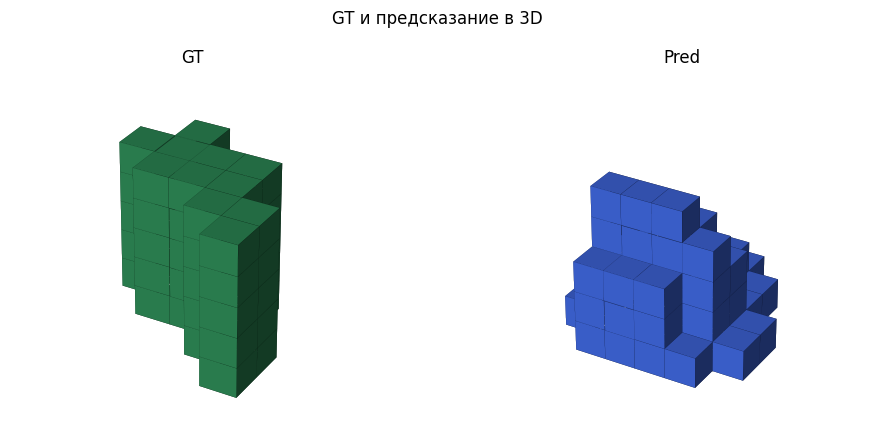

In [46]:
plot_gt_pred_3d(gt, pred, 'GT и предсказание в 3D')


In [47]:
out_mesh = voxel_ops.matrix_to_marching_cubes(pred.astype(bool), pitch=1.0)
out_path = DATA_DIR / 'predicted_from_image.stl'
out_mesh.export(out_path)
print('Saved prediction mesh to:', out_path)

Saved prediction mesh to: dataset\predicted_from_image.stl


Sample #0 | IoU=0.2590 | Dice=0.4114


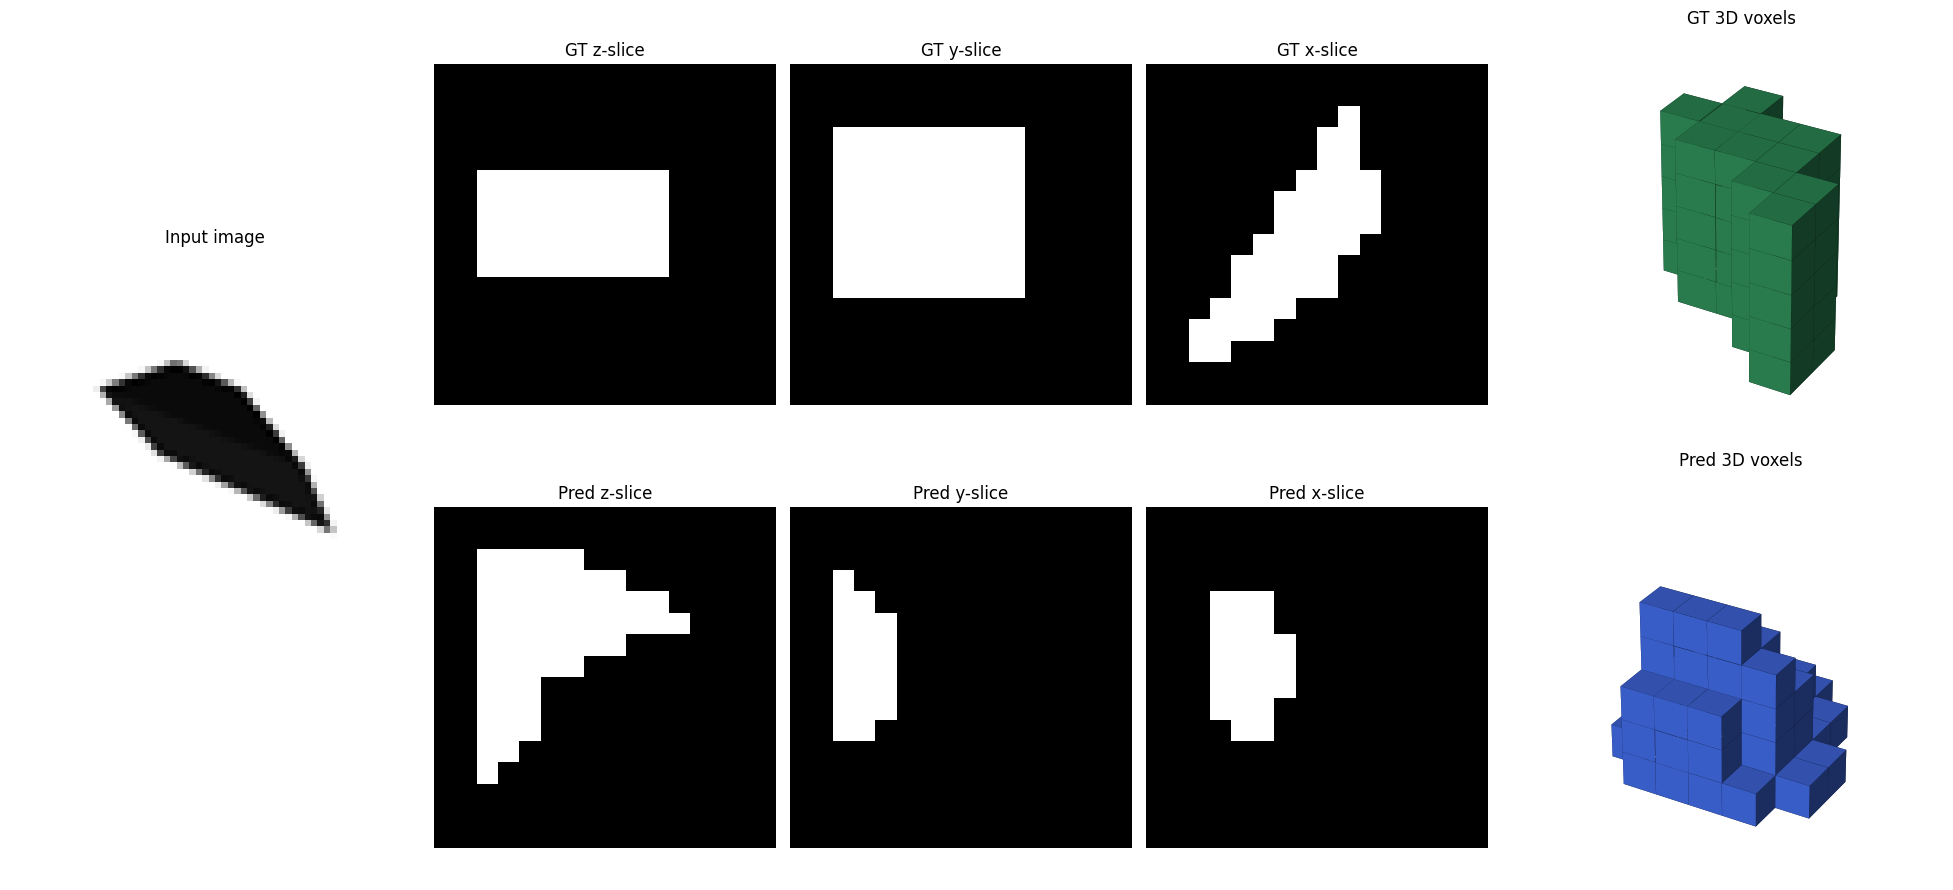

In [49]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

sample_id = 0
img, gt = val_ds[sample_id]
with torch.no_grad():
    pred_logits = model(img.unsqueeze(0).to(DEVICE))
    pred = (torch.sigmoid(pred_logits)[0, 0].cpu().numpy() > 0.4).astype(np.uint8)

gt = gt[0].numpy().astype(np.uint8)
img_np = img[0].numpy()

intersection = np.logical_and(pred == 1, gt == 1).sum()
union = np.logical_or(pred == 1, gt == 1).sum()
iou = intersection / (union + 1e-8)
dice = (2 * intersection) / (pred.sum() + gt.sum() + 1e-8)
print(f'Sample #{sample_id} | IoU={iou:.4f} | Dice={dice:.4f}')

mid = VOXEL_SIZE // 2
fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(2, 5, width_ratios=[1.2, 1, 1, 1, 1.4])

ax_input = fig.add_subplot(gs[:, 0])
ax_input.imshow(img_np, cmap='gray')
ax_input.set_title('Input image')
ax_input.axis('off')

ax_gt_z = fig.add_subplot(gs[0, 1])
ax_gt_z.imshow(gt[mid], cmap='gray')
ax_gt_z.set_title('GT z-slice')
ax_gt_z.axis('off')

ax_gt_y = fig.add_subplot(gs[0, 2])
ax_gt_y.imshow(gt[:, mid, :], cmap='gray')
ax_gt_y.set_title('GT y-slice')
ax_gt_y.axis('off')

ax_gt_x = fig.add_subplot(gs[0, 3])
ax_gt_x.imshow(gt[:, :, mid], cmap='gray')
ax_gt_x.set_title('GT x-slice')
ax_gt_x.axis('off')

ax_gt_3d = fig.add_subplot(gs[0, 4], projection='3d')
show_voxels(ax_gt_3d, gt, 'GT 3D voxels', color='seagreen', step=2)

ax_pr_z = fig.add_subplot(gs[1, 1])
ax_pr_z.imshow(pred[mid], cmap='gray')
ax_pr_z.set_title('Pred z-slice')
ax_pr_z.axis('off')

ax_pr_y = fig.add_subplot(gs[1, 2])
ax_pr_y.imshow(pred[:, mid, :], cmap='gray')
ax_pr_y.set_title('Pred y-slice')
ax_pr_y.axis('off')

ax_pr_x = fig.add_subplot(gs[1, 3])
ax_pr_x.imshow(pred[:, :, mid], cmap='gray')
ax_pr_x.set_title('Pred x-slice')
ax_pr_x.axis('off')

ax_pr_3d = fig.add_subplot(gs[1, 4], projection='3d')
show_voxels(ax_pr_3d, pred, 'Pred 3D voxels', color='royalblue', step=2)

plt.tight_layout()
plt.show()


### Модель 2


| Часть | Базовая | V2 |
|-------|----------------------------------|-----|
| Энкодер после уровня 2 | только `SE` | `SE` + блок `PooledSpatialAttention2d`: карта уменьшается в 2 раза по H,W, на ней тот же multi-head attention, затем билинейный апсемпл обратно и **прибавление** к исходной карте |
| Энкодер уровни 3–4 | как в базовой | без изменений (SE на 1–2, spatial attention на 3–4) |
| Декодер после каждого upsample | два `ConvBlock3D` | **три** `ConvBlock3D` подряд |
| После первого объёмного уровня декодера | — | остаточная связь `+ 0.25 * DilatedConvBlock3D` (свёртка 3×3×3 с **dilation=2**) |



In [ ]:
from torchvision.models import resnet18, ResNet18_Weights


class PooledSpatialAttention2d(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4, ffn_mult: int = 2):
        super().__init__()
        self.attn = SpatialSelfAttention2d(channels, num_heads=num_heads, ffn_mult=ffn_mult)

    def forward(self, x):
        b, c, h, w = x.shape
        if min(h, w) < 2:
            return x
        y = F.avg_pool2d(x, kernel_size=2, stride=2, ceil_mode=False)
        if y.shape[2] < 2 or y.shape[3] < 2:
            return x
        y = self.attn(y)
        y = F.interpolate(y, size=(h, w), mode="bilinear", align_corners=False)
        return x + y


class DilatedConvBlock3D(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(ch, ch, 3, padding=2, dilation=2),
            nn.BatchNorm3d(ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

# Здесь были исходные UNetLikeImageToVoxelV2 и UNetLikeImageToVoxelV3ResNet #

In [ ]:
# ИЗМЕНЕННАЯ UNetLikeImageToVoxelV2 #
class UNetLikeImageToVoxelV2(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        # same encoder as before
        self.enc1 = ConvBlock2D(in_ch, 32)
        self.enc2 = ConvBlock2D(32, 64)
        self.enc3 = ConvBlock2D(64, 128)
        self.enc4 = ConvBlock2D(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.se1 = SEBlock2d(32)
        self.se2 = SEBlock2d(64)
        self.pool_attn2 = PooledSpatialAttention2d(64, num_heads=4)
        self.sa3 = SpatialSelfAttention2d(128, num_heads=4)
        self.sa4 = SpatialSelfAttention2d(256, num_heads=8)

        self.bridge = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.skip1 = nn.Conv2d(32, 16, 1)
        self.skip2 = nn.Conv2d(64, 32, 1)
        self.skip3 = nn.Conv2d(128, 64, 1)
        self.skip4 = nn.Conv2d(256, 128, 1)

        # 4 x 4 x 4 -> 8 x 8 x 8 -> 16 x 16 x 16
        self.up1 = nn.ConvTranspose3d(256, 128, 2, stride=2)   # 4 -> 8
        self.dec1_a = ConvBlock3D(128, 128)
        self.dec1_b = ConvBlock3D(128, 128)
        self.dec1_c = ConvBlock3D(128, 128)
        self.mid_dilate = DilatedConvBlock3D(128)

        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)    # 8 -> 16
        self.dec2_a = ConvBlock3D(64, 64)
        self.dec2_b = ConvBlock3D(64, 64)
        self.dec2_c = ConvBlock3D(64, 64)

        self.up3 = None
        self.up4 = None
        self.skip1 = None
        self.skip2 = None  

        self.out = nn.Conv3d(64, out_ch, 1)

    def to_3d_skip_16(self, feat2d, proj, size):
        x = proj(feat2d)
        x = F.adaptive_avg_pool2d(x, (size, size))     
        x = x.unsqueeze(2).repeat(1, 1, size, 1, 1)    
        return x

    def forward(self, x):
        f1 = self.se1(self.enc1(x))
        f2 = self.se2(self.enc2(self.pool(f1)))
        f2 = self.pool_attn2(f2)
        f3 = self.sa3(self.enc3(self.pool(f2)))
        f4 = self.sa4(self.enc4(self.pool(f3)))

        b = self.bridge(f4)                                  
        b = b.unsqueeze(2).repeat(1, 1, 4, 1, 1)             

        # 4 x 4 x 4 -> 8 x 8 x 8
        x = self.up1(b)                                       
        skip4 = self.to_3d_skip_16(f4, self.skip4, 8)
        x = x + skip4
        x = self.dec1_c(self.dec1_b(self.dec1_a(x)))          
        x = x + 0.25 * self.mid_dilate(x)

        # 8 x 8 x 8 -> 16 x 16 x 16
        x = self.up2(x)                                      
        skip3 = self.to_3d_skip_16(f3, self.skip3, 16)
        x = x + skip3
        x = self.dec2_c(self.dec2_b(self.dec2_a(x)))          

        return self.out(x)                                  

In [52]:
model_v2 = UNetLikeImageToVoxelV2().to(DEVICE)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3)
try:
    num_params_v1 = sum(p.numel() for p in model.parameters())
except NameError:
    _tmp = UNetLikeImageToVoxel().to(DEVICE)
    num_params_v1 = sum(p.numel() for p in _tmp.parameters())
    del _tmp
num_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"Baseline (UNetLikeImageToVoxel) params: {num_params_v1:,}")
print(f"V2 params: {num_params_v2:,}")

Baseline (UNetLikeImageToVoxel) params: 5,010,493
V2 params: 6,591,181


In [53]:
EPOCHS_V2 = 5
best_val_v2 = 1e9
best_path_v2 = DATA_DIR / 'best_image_to_voxel_v2_attn_encoder_3ddec_deep.pt'

for epoch in range(1, EPOCHS_V2 + 1):
    model_v2.train()
    train_loss = 0.0
    for imgs, vox in train_loader:
        imgs = imgs.to(DEVICE)
        vox = vox.to(DEVICE)
        optimizer_v2.zero_grad()
        logits = model_v2(imgs)
        loss = combined_loss(logits, vox)
        loss.backward()
        optimizer_v2.step()
        train_loss += loss.item()

    model_v2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, vox in val_loader:
            imgs = imgs.to(DEVICE)
            vox = vox.to(DEVICE)
            logits = model_v2(imgs)
            val_loss += combined_loss(logits, vox).item()

    train_loss /= max(len(train_loader), 1)
    val_loss /= max(len(val_loader), 1)

    if val_loss < best_val_v2:
        best_val_v2 = val_loss
        torch.save(model_v2.state_dict(), best_path_v2)

    print(f'[V2] Epoch {epoch:02d}/{EPOCHS_V2} | train={train_loss:.4f} | val={val_loss:.4f}')

print('V2 best checkpoint:', best_path_v2, '| best val =', f'{best_val_v2:.4f}')

[V2] Epoch 01/5 | train=0.4056 | val=0.3369
[V2] Epoch 02/5 | train=0.3177 | val=0.3310
[V2] Epoch 03/5 | train=0.2979 | val=0.2703
[V2] Epoch 04/5 | train=0.2898 | val=0.2847
[V2] Epoch 05/5 | train=0.2747 | val=0.2646
V2 best checkpoint: dataset\best_image_to_voxel_v2_attn_encoder_3ddec_deep.pt | best val = 0.2646


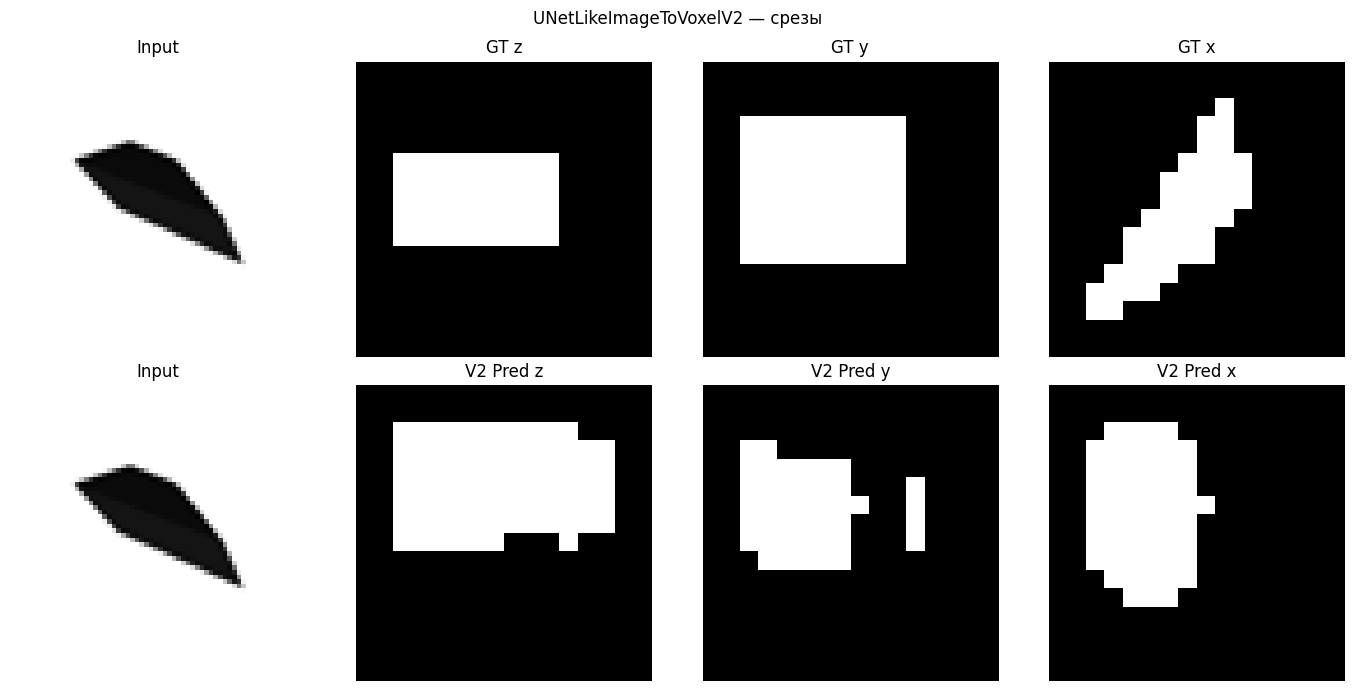

In [54]:
model_v2.load_state_dict(torch.load(best_path_v2, map_location=DEVICE))
model_v2.eval()

img, gt = val_ds[0]
with torch.no_grad():
    pred_logits_v2 = model_v2(img.unsqueeze(0).to(DEVICE))
    pred_v2 = (torch.sigmoid(pred_logits_v2)[0, 0].cpu().numpy() > 0.4).astype(np.uint8)

gt_np = gt[0].numpy().astype(np.uint8)
mid = VOXEL_SIZE // 2

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
ax[0, 0].imshow(img[0], cmap='gray')
ax[0, 0].set_title('Input')
ax[0, 0].axis('off')
ax[0, 1].imshow(gt_np[mid], cmap='gray')
ax[0, 1].set_title('GT z')
ax[0, 1].axis('off')
ax[0, 2].imshow(gt_np[:, mid, :], cmap='gray')
ax[0, 2].set_title('GT y')
ax[0, 2].axis('off')
ax[0, 3].imshow(gt_np[:, :, mid], cmap='gray')
ax[0, 3].set_title('GT x')
ax[0, 3].axis('off')

ax[1, 0].imshow(img[0], cmap='gray')
ax[1, 0].set_title('Input')
ax[1, 0].axis('off')
ax[1, 1].imshow(pred_v2[mid], cmap='gray')
ax[1, 1].set_title('V2 Pred z')
ax[1, 1].axis('off')
ax[1, 2].imshow(pred_v2[:, mid, :], cmap='gray')
ax[1, 2].set_title('V2 Pred y')
ax[1, 2].axis('off')
ax[1, 3].imshow(pred_v2[:, :, mid], cmap='gray')
ax[1, 3].set_title('V2 Pred x')
ax[1, 3].axis('off')
plt.suptitle('UNetLikeImageToVoxelV2 — срезы')
plt.tight_layout()
plt.show()

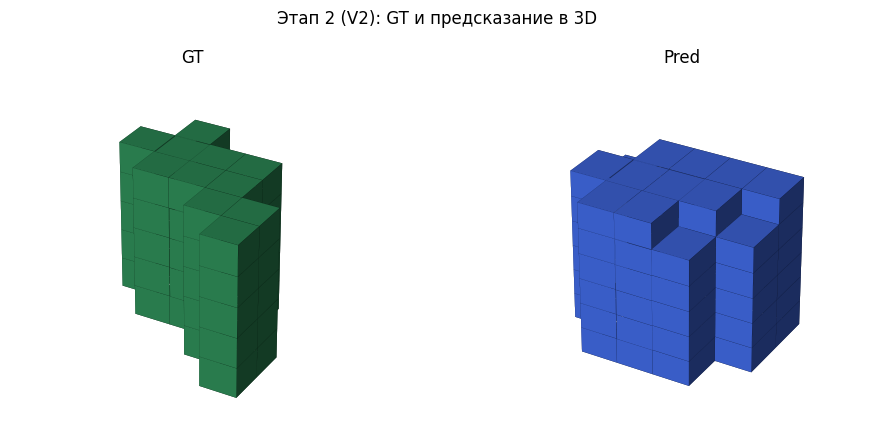

In [55]:
plot_gt_pred_3d(gt_np, pred_v2, 'Этап 2 (V2): GT и предсказание в 3D')


### Этап 3 ResNet18 ImageNet + декодер как у V2, составной лосс

| Слагаемое | Смысл |
|-----------|--------|
| Dice по вокселям | Перекрытие предсказания и маски |
| BCE | Классификация логитов по каждому вокселю |
| Focal BCE | Те же ошибки, но усилен редкий класс / трудные воксели |
| BoundaryLoss | Отдельный штраф за совпадение «ободка» объёма (через max-pool 3D); в коде значения ограничены \([0,1]\), чтобы лосс не уходил в отрицательные из‑за P/R/F1 |
| Boundary Dice | Сравнение границ через отклик `Conv3d` 3×3×3 |
| Focal Tversky | Обобщение Dice: разные веса на пропуски и лишние плюсы |


In [ ]:
# ИЗМЕНЕННАЯ UNetLikeImageToVoxelV3ResNet #
class UNetLikeImageToVoxelV3ResNet(nn.Module):
    def __init__(self, in_ch: int = 1, out_ch: int = 1, pretrained: bool = True):
        super().__init__()
        if in_ch != 1:
            raise ValueError('UNetLikeImageToVoxelV3ResNet: пока поддержан in_ch=1 (повтор до 3 каналов).')
        w = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        bb = resnet18(weights=w)
        self.conv1 = bb.conv1
        self.bn1 = bb.bn1
        self.relu = bb.relu
        self.maxpool = bb.maxpool
        self.layer1 = bb.layer1
        self.layer2 = bb.layer2
        self.layer3 = bb.layer3
        self.layer4 = bb.layer4

        self.proj1 = nn.Conv2d(64, 32, 1)  
        self.proj2 = nn.Conv2d(64, 64, 1)   
        self.proj3 = nn.Conv2d(128, 128, 1) 
        self.proj4 = nn.Conv2d(256, 256, 1) 
        self.proj_ctx = nn.Conv2d(512, 256, 1)

        self.se1 = SEBlock2d(32)
        self.se2 = SEBlock2d(64)
        self.pool_attn2 = PooledSpatialAttention2d(64, num_heads=4)
        self.sa3 = SpatialSelfAttention2d(128, num_heads=4)
        self.sa4 = SpatialSelfAttention2d(256, num_heads=8)

        self.bridge = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.skip3 = nn.Conv2d(128, 64, 1)   
        self.skip4 = nn.Conv2d(256, 128, 1)  

        # 4 x 4 x 4 -> 8 x 8 x 8 -> 16 x 16 x 16
        self.up1 = nn.ConvTranspose3d(256, 128, 2, stride=2)   # 4 -> 8
        self.dec1_a = ConvBlock3D(128, 128)
        self.dec1_b = ConvBlock3D(128, 128)
        self.dec1_c = ConvBlock3D(128, 128)
        self.mid_dilate = DilatedConvBlock3D(128)

        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)    # 8 -> 16
        self.dec2_a = ConvBlock3D(64, 64)
        self.dec2_b = ConvBlock3D(64, 64)
        self.dec2_c = ConvBlock3D(64, 64)

        self.up3 = None
        self.up4 = None

        self.out = nn.Conv3d(64, out_ch, 1)

    def to_3d_skip_16(self, feat2d, proj, size):
        x = proj(feat2d)
        x = F.adaptive_avg_pool2d(x, (size, size))
        x = x.unsqueeze(2).repeat(1, 1, size, 1, 1)
        return x

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x0 = self.relu(x)  

        x = self.maxpool(x0)
        l1 = self.layer1(x)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)

        f1 = self.se1(self.proj1(x0))          # 64 x 64
        f2 = self.pool_attn2(self.se2(self.proj2(l1)))  # 32 x 32
        f3 = self.sa3(self.proj3(l2))          # 16 x 16
        f4_main = self.proj4(l3)               # 8 x 8
        f4_ctx = F.interpolate(self.proj_ctx(l4), size=f4_main.shape[-2:], mode='bilinear', align_corners=False)
        f4 = self.sa4(f4_main + f4_ctx)        # 8 x 8

        b = self.bridge(f4)                 
        b = b.unsqueeze(2).repeat(1, 1, 4, 1, 1)

        # 4 x 4 x 4 -> 8 x 8 x8
        x = self.up1(b)                       
        skip4 = self.to_3d_skip_16(f4, self.skip4, 8)
        x = x + skip4
        x = self.dec1_c(self.dec1_b(self.dec1_a(x)))
        x = x + 0.25 * self.mid_dilate(x)

        # 8 x 8 x 8 -> 16 x 16 x 16
        x = self.up2(x)                        
        skip3 = self.to_3d_skip_16(f3, self.skip3, 16)
        x = x + skip3
        x = self.dec2_c(self.dec2_b(self.dec2_a(x)))

        return self.out(x)                 

In [57]:
def dice_loss_flat_vox(y_real, y_pred):
    y_real = y_real.view(y_real.shape[0], -1)
    y_pred = torch.sigmoid(y_pred).view(y_pred.shape[0], -1)
    smooth = 1e-8
    intersection = torch.sum(y_real * y_pred, dim=1)
    union = torch.sum(y_real + y_pred, dim=1)
    return torch.mean(1 - (2 * (intersection + smooth) / (union + smooth)))


def focal_loss_vox(y_real, y_pred, alpha=0.8, gamma=2):
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction='none')
    bce_exp = torch.exp(-bce)
    return torch.mean(alpha * (1 - bce_exp) ** gamma * bce)


def focal_tversky_vox(y_real, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    y_pred = y_pred.sigmoid().clamp(0, 1)
    y_real = y_real.clamp(0, 1)
    true_pos = (y_real * y_pred).sum(dim=(2, 3, 4))
    false_neg = ((1 - y_real) * y_pred).sum(dim=(2, 3, 4))
    false_pos = (y_real * (1 - y_pred)).sum(dim=(2, 3, 4))
    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)
    tversky = tversky.clamp(0, 1)
    return ((1 - tversky) ** gamma).mean()


class BoundaryLoss3D(nn.Module):
    def __init__(self, theta0=3, theta=5):
        super().__init__()
        self.theta0 = theta0
        self.theta = theta

    def forward(self, pred, gt):
        pred = torch.sigmoid(pred).clamp(0, 1)
        gt = gt.float() if gt.dim() == 5 else gt.unsqueeze(1).float()
        gt = gt.clamp(0, 1)
        gt_b = F.max_pool3d(1 - gt, kernel_size=self.theta0, stride=1, padding=(self.theta0 - 1) // 2)
        gt_b -= 1 - gt
        pred_b = F.max_pool3d(1 - pred, kernel_size=self.theta0, stride=1, padding=(self.theta0 - 1) // 2)
        pred_b -= 1 - pred
        gt_b = gt_b.clamp(0, 1)
        pred_b = pred_b.clamp(0, 1)
        gt_b_ext = F.max_pool3d(gt_b, kernel_size=self.theta, stride=1, padding=(self.theta - 1) // 2)
        pred_b_ext = F.max_pool3d(pred_b, kernel_size=self.theta, stride=1, padding=(self.theta - 1) // 2)
        gt_b_ext = gt_b_ext.clamp(0, 1)
        pred_b_ext = pred_b_ext.clamp(0, 1)
        gt_b = gt_b.view(gt_b.shape[0], -1)
        pred_b = pred_b.view(pred_b.shape[0], -1)
        gt_b_ext = gt_b_ext.view(gt_b_ext.shape[0], -1)
        pred_b_ext = pred_b_ext.view(pred_b_ext.shape[0], -1)
        P = torch.sum(pred_b * gt_b_ext, dim=1) / (torch.sum(pred_b, dim=1) + 1e-7)
        R = torch.sum(pred_b_ext * gt_b, dim=1) / (torch.sum(gt_b, dim=1) + 1e-7)
        P = P.clamp(0, 1)
        R = R.clamp(0, 1)
        BF1 = (2 * P * R / (P + R + 1e-7)).clamp(0, 1)
        return torch.mean((1 - BF1).clamp(0, 1))


def boundary_dice_vox(y_real, y_pred, boundary_weight=1.0, smooth=1.0):
    c = y_real.shape[1]
    k = torch.ones((c, 1, 3, 3, 3), device=y_real.device, dtype=y_real.dtype)
    y_real = y_real.clamp(0, 1)
    ps = y_pred.sigmoid().clamp(0, 1)
    br = F.conv3d(y_real, weight=k, groups=c, padding=1) - y_real
    bp = F.conv3d(ps, weight=k, groups=c, padding=1) - ps
    br = torch.abs(br)
    bp = torch.abs(bp)
    inter = (bp * br).sum(dim=(2, 3, 4))
    union = bp.sum(dim=(2, 3, 4)) + br.sum(dim=(2, 3, 4))
    dice = ((2.0 * inter + smooth) / (union + smooth)).clamp(0, 1)
    return boundary_weight * torch.mean(1 - dice)


_boundary_loss_3d = BoundaryLoss3D()


def combined_multitask_voxel_loss(logits, targets, w_dice=0.3, w_focal=0.22, w_bce=0.22, w_bnd=0.12, w_bd=0.09, w_ft=0.05):
    d = dice_loss_flat_vox(targets, logits)
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    fl = focal_loss_vox(targets, logits)
    bn = _boundary_loss_3d(logits, targets)
    bd = boundary_dice_vox(targets, logits)
    ft = focal_tversky_vox(targets, logits)
    return w_dice * d + w_focal * fl + w_bce * bce + w_bnd * bn + w_bd * bd + w_ft * ft

In [58]:
model_v3 = UNetLikeImageToVoxelV3ResNet(pretrained=True).to(DEVICE)
_bb_pref = ('conv1.', 'bn1.', 'layer1.', 'layer2.', 'layer3.', 'layer4.')


def _set_backbone_trainable(net, trainable: bool):
    for name, p in net.named_parameters():
        if name.startswith(_bb_pref):
            p.requires_grad = trainable


# Warmup: сначала учим голову/декодер, потом дообучаем весь backbone
_set_backbone_trainable(model_v3, False)

bb_params = [p for n, p in model_v3.named_parameters() if n.startswith(_bb_pref)]
head_params = [p for n, p in model_v3.named_parameters() if not n.startswith(_bb_pref)]
optimizer_v3 = torch.optim.Adam(
    [{'params': bb_params, 'lr': 3e-5}, {'params': head_params, 'lr': 5e-4}],
)

EPOCHS_V3 = 14
UNFREEZE_AT_EPOCH = 5
best_val_v3 = 1e9
best_path_v3 = DATA_DIR / 'best_image_to_voxel_v3_resnet_multitask.pt'

for epoch in range(1, EPOCHS_V3 + 1):
    if epoch == UNFREEZE_AT_EPOCH:
        _set_backbone_trainable(model_v3, True)

    model_v3.train()
    train_loss = 0.0
    for imgs, vox in train_loader:
        imgs = imgs.to(DEVICE)
        vox = vox.to(DEVICE)
        optimizer_v3.zero_grad()
        logits = model_v3(imgs)
        loss = combined_multitask_voxel_loss(
            logits,
            vox,
            w_dice=0.42,
            w_focal=0.14,
            w_bce=0.30,
            w_bnd=0.05,
            w_bd=0.05,
            w_ft=0.04,
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model_v3.parameters(), max_norm=1.0)
        optimizer_v3.step()
        train_loss += loss.item()

    model_v3.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, vox in val_loader:
            imgs = imgs.to(DEVICE)
            vox = vox.to(DEVICE)
            logits = model_v3(imgs)
            val_loss += combined_multitask_voxel_loss(
                logits,
                vox,
                w_dice=0.42,
                w_focal=0.14,
                w_bce=0.30,
                w_bnd=0.05,
                w_bd=0.05,
                w_ft=0.04,
            ).item()

    train_loss /= max(len(train_loader), 1)
    val_loss /= max(len(val_loader), 1)

    if val_loss < best_val_v3:
        best_val_v3 = val_loss
        torch.save(model_v3.state_dict(), best_path_v3)

    print(f'[V3] Epoch {epoch:02d}/{EPOCHS_V3} | train={train_loss:.4f} | val={val_loss:.4f}')

print('V3 best:', best_path_v3, '| best val (multitask) =', f'{best_val_v3:.4f}')

[V3] Epoch 01/14 | train=0.3811 | val=0.3227
[V3] Epoch 02/14 | train=0.2891 | val=0.2826
[V3] Epoch 03/14 | train=0.2577 | val=0.2425
[V3] Epoch 04/14 | train=0.2451 | val=0.2552
[V3] Epoch 05/14 | train=0.2244 | val=0.2165
[V3] Epoch 06/14 | train=0.2056 | val=0.2003
[V3] Epoch 07/14 | train=0.1977 | val=0.1914
[V3] Epoch 08/14 | train=0.1939 | val=0.2158
[V3] Epoch 09/14 | train=0.1851 | val=0.1912
[V3] Epoch 10/14 | train=0.1854 | val=0.1804
[V3] Epoch 11/14 | train=0.1733 | val=0.1783
[V3] Epoch 12/14 | train=0.1685 | val=0.1791
[V3] Epoch 13/14 | train=0.1644 | val=0.1919
[V3] Epoch 14/14 | train=0.1556 | val=0.1895
V3 best: dataset\best_image_to_voxel_v3_resnet_multitask.pt | best val (multitask) = 0.1783


V3 sample raw  | IoU=0.4597 | Dice=0.6299
V3 sample post | IoU=0.4562 | Dice=0.6266


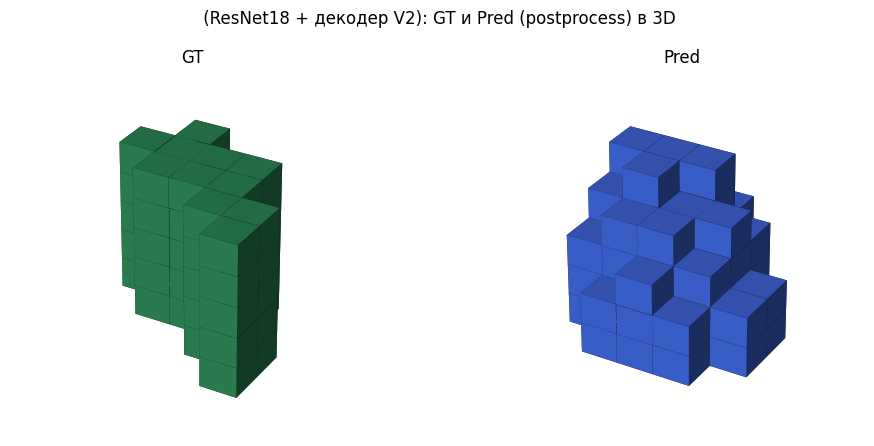

In [59]:
from collections import deque


def _largest_cc_3d(vol_bin: np.ndarray) -> np.ndarray:
    vol = (vol_bin > 0).astype(np.uint8)
    dz, dy, dx = vol.shape
    visited = np.zeros_like(vol, dtype=np.uint8)
    best_comp = []
    neighbors = [(-1, 0, 0), (1, 0, 0), (0, -1, 0), (0, 1, 0), (0, 0, -1), (0, 0, 1)]

    for z in range(dz):
        for y in range(dy):
            for x in range(dx):
                if vol[z, y, x] == 0 or visited[z, y, x]:
                    continue
                q = deque([(z, y, x)])
                visited[z, y, x] = 1
                comp = []
                while q:
                    cz, cy, cx = q.popleft()
                    comp.append((cz, cy, cx))
                    for dz_, dy_, dx_ in neighbors:
                        nz, ny, nx = cz + dz_, cy + dy_, cx + dx_
                        if 0 <= nz < dz and 0 <= ny < dy and 0 <= nx < dx:
                            if vol[nz, ny, nx] and not visited[nz, ny, nx]:
                                visited[nz, ny, nx] = 1
                                q.append((nz, ny, nx))
                if len(comp) > len(best_comp):
                    best_comp = comp

    out = np.zeros_like(vol, dtype=np.uint8)
    for z, y, x in best_comp:
        out[z, y, x] = 1
    return out


def _morph_close_3d(vol_bin: np.ndarray, iters: int = 1) -> np.ndarray:
    x = torch.from_numpy(vol_bin.astype(np.float32))[None, None]
    k = torch.ones((1, 1, 3, 3, 3), dtype=torch.float32)
    for _ in range(iters):
        x = (F.conv3d(x, k, padding=1) > 0).float()
    for _ in range(iters):
        x = (F.conv3d(x, k, padding=1) >= 27).float()
    return x[0, 0].numpy().astype(np.uint8)


def postprocess_voxel_prob(prob: np.ndarray, thr: float = 0.38, close_iters: int = 1, keep_lcc: bool = True) -> np.ndarray:
    pred = (prob > thr).astype(np.uint8)
    pred = _morph_close_3d(pred, iters=close_iters)
    if keep_lcc:
        pred = _largest_cc_3d(pred)
    return pred


def iou_dice_pair(pred_bin, gt_bin):
    p = pred_bin.astype(bool)
    g = gt_bin.astype(bool)
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    iou = inter / (union + 1e-8)
    dice = (2 * inter) / (p.sum() + g.sum() + 1e-8)
    return iou, dice


if best_path_v3.exists():
    model_v3.load_state_dict(torch.load(best_path_v3, map_location=DEVICE))
    model_v3.eval()
    img_v3, gt_v3 = val_ds[0]
    with torch.no_grad():
        log3 = model_v3(img_v3.unsqueeze(0).to(DEVICE))
        prob_v3 = torch.sigmoid(log3)[0, 0].cpu().numpy()
        pred_v3_raw = (prob_v3 > 0.4).astype(np.uint8)
        pred_v3_bin = postprocess_voxel_prob(prob_v3, thr=0.38, close_iters=1, keep_lcc=True)
    gt_v3_np = gt_v3[0].numpy().astype(np.uint8)

    i_raw, d_raw = iou_dice_pair(pred_v3_raw, gt_v3_np)
    i_pp, d_pp = iou_dice_pair(pred_v3_bin, gt_v3_np)
    print(f'V3 sample raw  | IoU={i_raw:.4f} | Dice={d_raw:.4f}')
    print(f'V3 sample post | IoU={i_pp:.4f} | Dice={d_pp:.4f}')

    plot_gt_pred_3d(gt_v3_np, pred_v3_bin, ' (ResNet18 + декодер V2): GT и Pred (postprocess) в 3D')
else:
    print('Нет чекпоинта V3:', best_path_v3)


In [60]:
@torch.no_grad()
def val_metrics(loader, net, thr=0.4, postprocess=False, close_iters=1, keep_lcc=True):
    net.eval()
    ious, dices = [], []
    for imgs, vox in loader:
        imgs = imgs.to(DEVICE)
        vox = vox.to(DEVICE)
        logits = net(imgs)
        probs = torch.sigmoid(logits)

        for b in range(imgs.shape[0]):
            if postprocess:
                p_np = postprocess_voxel_prob(
                    probs[b, 0].detach().cpu().numpy(),
                    thr=thr,
                    close_iters=close_iters,
                    keep_lcc=keep_lcc,
                )
                p = torch.from_numpy(p_np).to(vox.device, dtype=vox.dtype).flatten()
            else:
                p = (probs[b, 0] > thr).float().flatten()

            g = vox[b, 0].flatten()
            inter = (p * g).sum()
            union = p.sum() + g.sum() - inter
            ious.append((inter / (union + 1e-8)).item())
            dices.append((2 * inter / (p.sum() + g.sum() + 1e-8)).item())
    return float(np.mean(ious)), float(np.mean(dices))


@torch.no_grad()
def tune_threshold(loader, net, thresholds, postprocess=False, close_iters=1, keep_lcc=True):
    best = {'thr': None, 'iou': -1.0, 'dice': -1.0}
    for thr in thresholds:
        iou, dice = val_metrics(
            loader,
            net,
            thr=thr,
            postprocess=postprocess,
            close_iters=close_iters,
            keep_lcc=keep_lcc,
        )
        if dice > best['dice']:
            best = {'thr': thr, 'iou': iou, 'dice': dice}
    return best


if best_path.exists():
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    v_b_iou, v_b_dice = val_metrics(val_loader, model)
    print(f'  Baseline | IoU={v_b_iou:.4f} | Dice={v_b_dice:.4f}')
else:
    print('  Baseline: нет файла', best_path)

model_v2.load_state_dict(torch.load(best_path_v2, map_location=DEVICE))
v2_iou, v2_dice = val_metrics(val_loader, model_v2)
print(f'  V2 (как baseline: BCE+Dice) | IoU={v2_iou:.4f} | Dice={v2_dice:.4f}')

threshold_grid = [0.30, 0.35, 0.40, 0.45, 0.50]
if best_path_v3.exists():
    model_v3.load_state_dict(torch.load(best_path_v3, map_location=DEVICE))
    best_raw = tune_threshold(val_loader, model_v3, threshold_grid, postprocess=False)
    best_pp = tune_threshold(val_loader, model_v3, threshold_grid, postprocess=True, close_iters=1, keep_lcc=True)
    print(f"  V3 raw  | thr={best_raw['thr']:.2f} | IoU={best_raw['iou']:.4f} | Dice={best_raw['dice']:.4f}")
    print(f"  V3 post | thr={best_pp['thr']:.2f} | IoU={best_pp['iou']:.4f} | Dice={best_pp['dice']:.4f}")
else:
    print('  V3: нет файла', best_path_v3)
    best_raw = {'thr': 0.4}
    best_pp = {'thr': 0.38}

sample_id = 0
img_s, gt_s = val_ds[sample_id]
gt_s_np = gt_s[0].numpy().astype(np.uint8)


def iou_dice_pair(pred_bin, gt_bin):
    p = pred_bin.astype(bool)
    g = gt_bin.astype(bool)
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    iou = inter / (union + 1e-8)
    dice = (2 * inter) / (p.sum() + g.sum() + 1e-8)
    return iou, dice


with torch.no_grad():
    if best_path.exists():
        pb = model(img_s.unsqueeze(0).to(DEVICE))
        pred_b = (torch.sigmoid(pb)[0, 0].cpu().numpy() > 0.4).astype(np.uint8)
        i_b, d_b = iou_dice_pair(pred_b, gt_s_np)
        print(f'Sample #{sample_id} baseline | IoU={i_b:.4f} | Dice={d_b:.4f}')
    pv2 = model_v2(img_s.unsqueeze(0).to(DEVICE))
    pred_v2 = (torch.sigmoid(pv2)[0, 0].cpu().numpy() > 0.4).astype(np.uint8)
    i_v2, d_v2 = iou_dice_pair(pred_v2, gt_s_np)
    print(f'Sample #{sample_id} V2       | IoU={i_v2:.4f} | Dice={d_v2:.4f}')
    if best_path_v3.exists():
        pv3 = model_v3(img_s.unsqueeze(0).to(DEVICE))
        prob_v3 = torch.sigmoid(pv3)[0, 0].cpu().numpy()
        pred_v3_raw = (prob_v3 > best_raw['thr']).astype(np.uint8)
        pred_v3_pp = postprocess_voxel_prob(prob_v3, thr=best_pp['thr'], close_iters=1, keep_lcc=True)
        i_v3r, d_v3r = iou_dice_pair(pred_v3_raw, gt_s_np)
        i_v3p, d_v3p = iou_dice_pair(pred_v3_pp, gt_s_np)
        print(f"Sample #{sample_id} V3 raw  | IoU={i_v3r:.4f} | Dice={d_v3r:.4f}")
        print(f"Sample #{sample_id} V3 post | IoU={i_v3p:.4f} | Dice={d_v3p:.4f}")

  Baseline | IoU=0.5569 | Dice=0.6856
  V2 (как baseline: BCE+Dice) | IoU=0.5363 | Dice=0.6677
  V3 raw  | thr=0.50 | IoU=0.6623 | Dice=0.7666
  V3 post | thr=0.50 | IoU=0.6625 | Dice=0.7667
Sample #0 baseline | IoU=0.2590 | Dice=0.4114
Sample #0 V2       | IoU=0.2428 | Dice=0.3908
Sample #0 V3 raw  | IoU=0.4657 | Dice=0.6355
Sample #0 V3 post | IoU=0.4657 | Dice=0.6355
